In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/crop_data.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.shape

(2200, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
X = df.drop("label", axis=1)
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 7)
y shape: (2200,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1760, 7) (440, 7)


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [12]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=22, num_parallel_tree=None, ...)

In [14]:
y_pred_xgb = xgb.predict(X_test_xgb)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_results = {
    "Accuracy": accuracy_score(y_test_xgb, y_pred_xgb),
    "Precision": precision_score(y_test_xgb, y_pred_xgb, average="weighted"),
    "Recall": recall_score(y_test_xgb, y_pred_xgb, average="weighted"),
    "F1-score": f1_score(y_test_xgb, y_pred_xgb, average="weighted")
}

xgb_results

{'Accuracy': 0.9931818181818182,
 'Precision': 0.9935064935064934,
 'Recall': 0.9931818181818182,
 'F1-score': 0.9931162119865588}

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted")
    }

In [16]:
results = {
    "Random Forest": evaluate_model(rf, X_test, y_test),
    "Decision Tree": evaluate_model(dt, X_test, y_test),
    "XGBoost": xgb_results
}

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1-score
Random Forest,0.995455,0.995671,0.995455,0.995452
Decision Tree,0.979545,0.980598,0.979545,0.979423
XGBoost,0.993182,0.993506,0.993182,0.993116


In [17]:
results_df.to_csv("../results/tables/baseline_results.csv")

In [18]:
print(type(rf))
print(type(dt))
print(type(xgb))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>


In [19]:
#GLOBAL FEATURE IMPORTANCE (BASELINE EXPLANATION)
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
6,rainfall,0.230184
4,humidity,0.224227
2,K,0.175393
1,P,0.150850
0,N,0.096363
3,temperature,0.072375
5,ph,0.050608


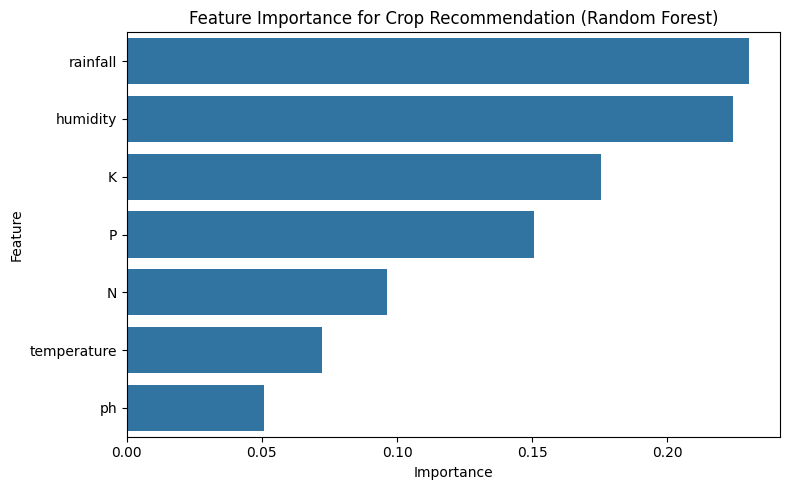

In [20]:
#VISUALIZE FEATURE IMPORTANCE (GRAPH 1)
#“Feature importance analysis reveals that rainfall, nitrogen content, and temperature are the most influential parameters in crop recommendation.”
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)
plt.title("Feature Importance for Crop Recommendation (Random Forest)")
plt.tight_layout()
plt.show()

In [21]:
#EXPLAINABLE AI USING SHAP (CORE CONTRIBUTION)
import shap

shap.initjs()

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

In [22]:
import numpy as np

# shap_values is a list of arrays (one per class)
# Take mean absolute SHAP value across classes
shap_values_mean = np.mean(
    [np.abs(sv) for sv in shap_values],
    axis=0
)

shap_values_mean.shape

(7, 22)

In [23]:
shap_global = shap_values_mean.mean(axis=1)

shap_global.shape

(7,)

In [24]:
shap_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP Importance": shap_global
}).sort_values(by="SHAP Importance", ascending=False)

shap_df

,Feature,SHAP Importance
4,humidity,0.033141
6,rainfall,0.027439
2,K,0.026305
0,N,0.025891
1,P,0.024395
3,temperature,0.010072
5,ph,0.004847


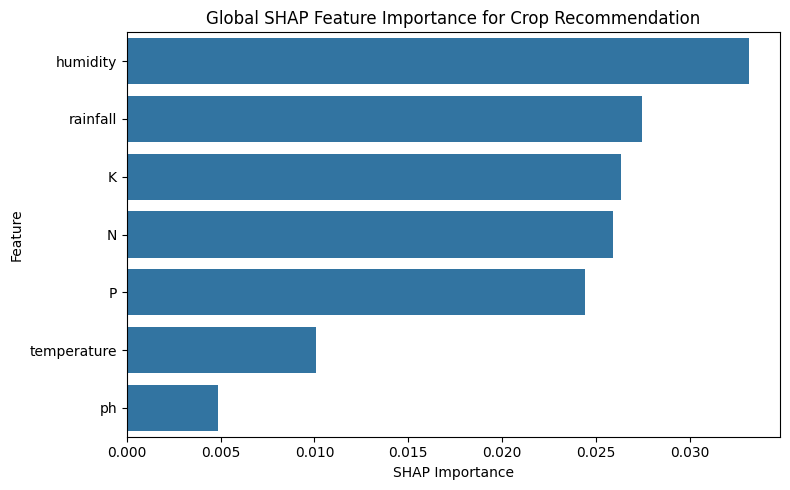

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    x="SHAP Importance",
    y="Feature",
    data=shap_df
)
plt.title("Global SHAP Feature Importance for Crop Recommendation")
plt.tight_layout()
plt.show()

In [26]:
plt.savefig("../results/figures/shap_feature_importance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [27]:
df_csi = df.copy()
df_csi["temp_norm"] = (df_csi["temperature"] - df_csi["temperature"].mean()) / df_csi["temperature"].std()
df_csi["humidity_norm"] = (df_csi["humidity"] - df_csi["humidity"].mean()) / df_csi["humidity"].std()
df_csi["rainfall_norm"] = (df_csi["rainfall"] - df_csi["rainfall"].mean()) / df_csi["rainfall"].std()

# Climate Stress Index (CSI)
df_csi["CSI"] = (
    0.4 * abs(df_csi["temp_norm"]) +
    0.3 * abs(df_csi["humidity_norm"]) +
    0.3 * abs(df_csi["rainfall_norm"])
)

df_csi[["CSI"]].describe()

,CSI
count,2200.000000
mean,0.776629
std,0.364549
min,0.044714
25%,0.514641
50%,0.706420
75%,0.989889
max,2.413357


In [28]:
X_csi = df_csi.drop("label", axis=1)
y_csi = df_csi["label"]

from sklearn.model_selection import train_test_split

X_train_csi, X_test_csi, y_train_csi, y_test_csi = train_test_split(
    X_csi, y_csi,
    test_size=0.2,
    random_state=42,
    stratify=y_csi
)

In [29]:
rf_csi = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_csi.fit(X_train_csi, y_train_csi)

RandomForestClassifier(random_state=42)

In [30]:
rf_csi_results = evaluate_model(rf_csi, X_test_csi, y_test_csi)
rf_csi_results

{'Accuracy': 0.9954545454545455,
 'Precision': 0.9956709956709956,
 'Recall': 0.9954545454545455,
 'F1-score': 0.9954517027687759}

In [31]:
comparison_df = pd.DataFrame({
    "Baseline RF": results_df.loc["Random Forest"],
    "RF + CSI": rf_csi_results
})

comparison_df

,Baseline RF,RF + CSI
Accuracy,0.995455,0.995455
Precision,0.995671,0.995671
Recall,0.995455,0.995455
F1-score,0.995452,0.995452


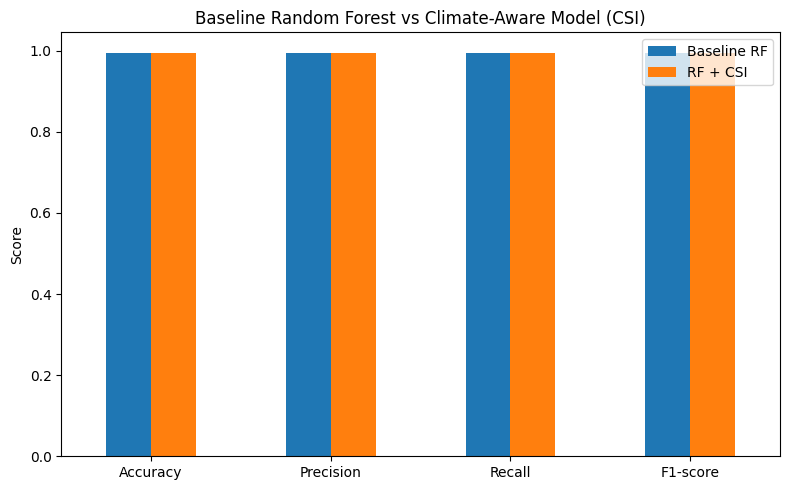

In [32]:
#VISUAL COMPARISON GRAPH (FIGURE FOR PAPER)
comparison_df.plot(kind="bar", figsize=(8,5))
plt.title("Baseline Random Forest vs Climate-Aware Model (CSI)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
plt.savefig("../results/figures/baseline_vs_csi.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [35]:
rf_ens = RandomForestClassifier(n_estimators=100, random_state=42)
dt_ens = DecisionTreeClassifier(random_state=42)

xgb_ens = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42
)

rf_ens.fit(X_train, y_train)
dt_ens.fit(X_train, y_train)
xgb_ens.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=22, num_parallel_tree=None, ...)

In [36]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("rf", rf_ens),
        ("dt", dt_ens),
        ("xgb", xgb_ens)
    ],
    voting="soft"
)

ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss',
                                            feature_...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_class=22,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [37]:
ensemble_results = evaluate_model(ensemble, X_test, y_test)
ensemble_results

{'Accuracy': 0.990909090909091,
 'Precision': 0.991538764266037,
 'Recall': 0.990909090909091,
 'F1-score': 0.9908948561066662}

In [38]:
final_results = results_df.copy()
final_results.loc["Ensemble (RF+DT+XGB)"] = ensemble_results

final_results

,Accuracy,Precision,Recall,F1-score
Random Forest,0.995455,0.995671,0.995455,0.995452
Decision Tree,0.979545,0.980598,0.979545,0.979423
XGBoost,0.993182,0.993506,0.993182,0.993116
Ensemble (RF+DT+XGB),0.990909,0.991539,0.990909,0.990895


In [39]:
final_results.to_csv("../results/tables/final_results_with_ensemble.csv")

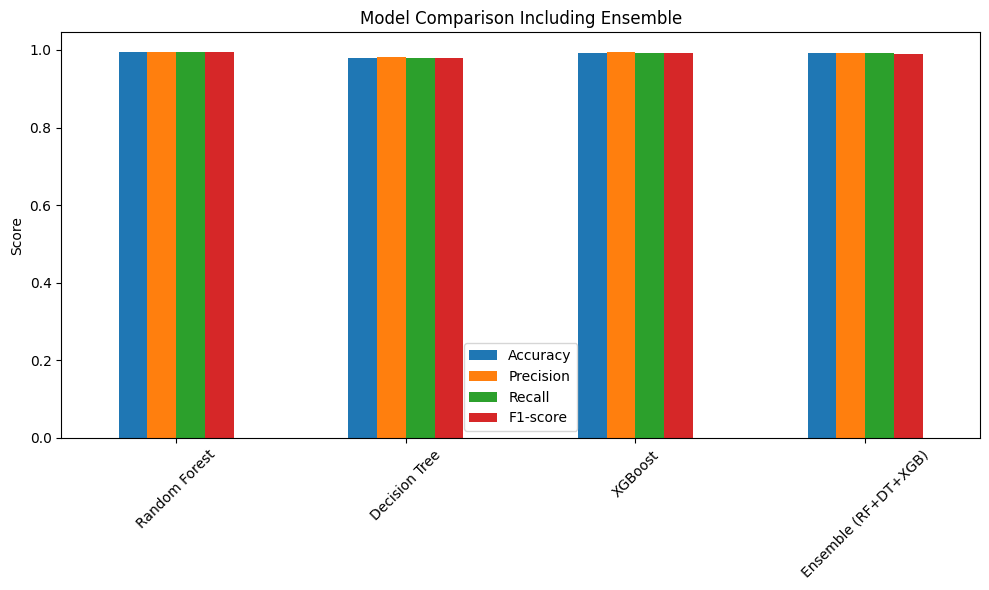

<Figure size 640x480 with 0 Axes>

In [40]:
final_results.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison Including Ensemble")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig("../results/figures/model_comparison_ensemble.png", dpi=300)

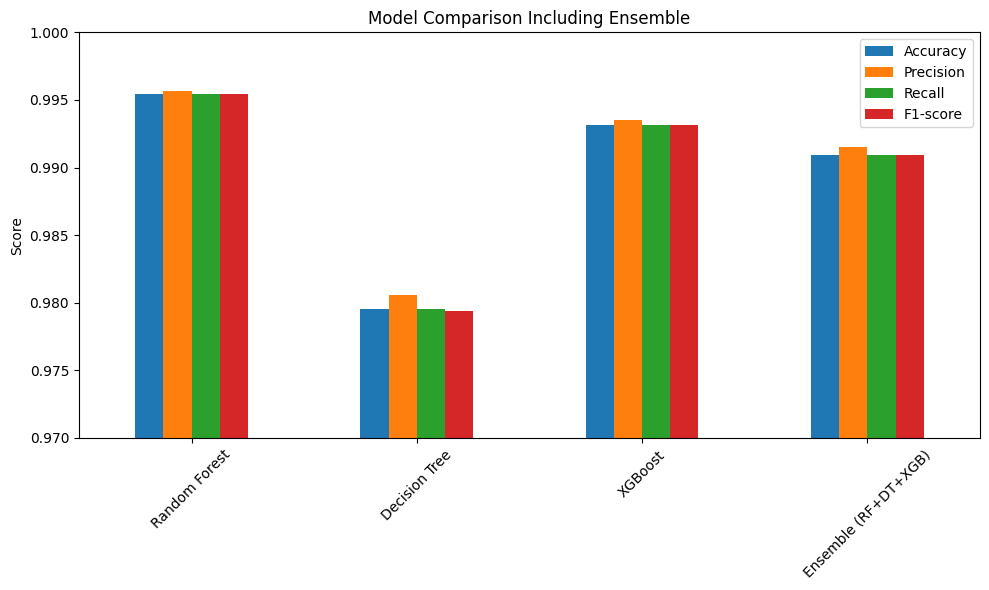

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt

ax = final_results.plot(kind="bar", figsize=(10,6))

ax.set_ylim(0.97, 1.0)   # ZOOMED RANGE
ax.set_ylabel("Score")
ax.set_title("Model Comparison Including Ensemble")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig(
    "../results/figures/model_comparison_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
y_pred_ensemble = ensemble.predict(X_test)

In [44]:
cm = confusion_matrix(y_test, y_pred_ensemble)
cm

array([[20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0, 19,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,

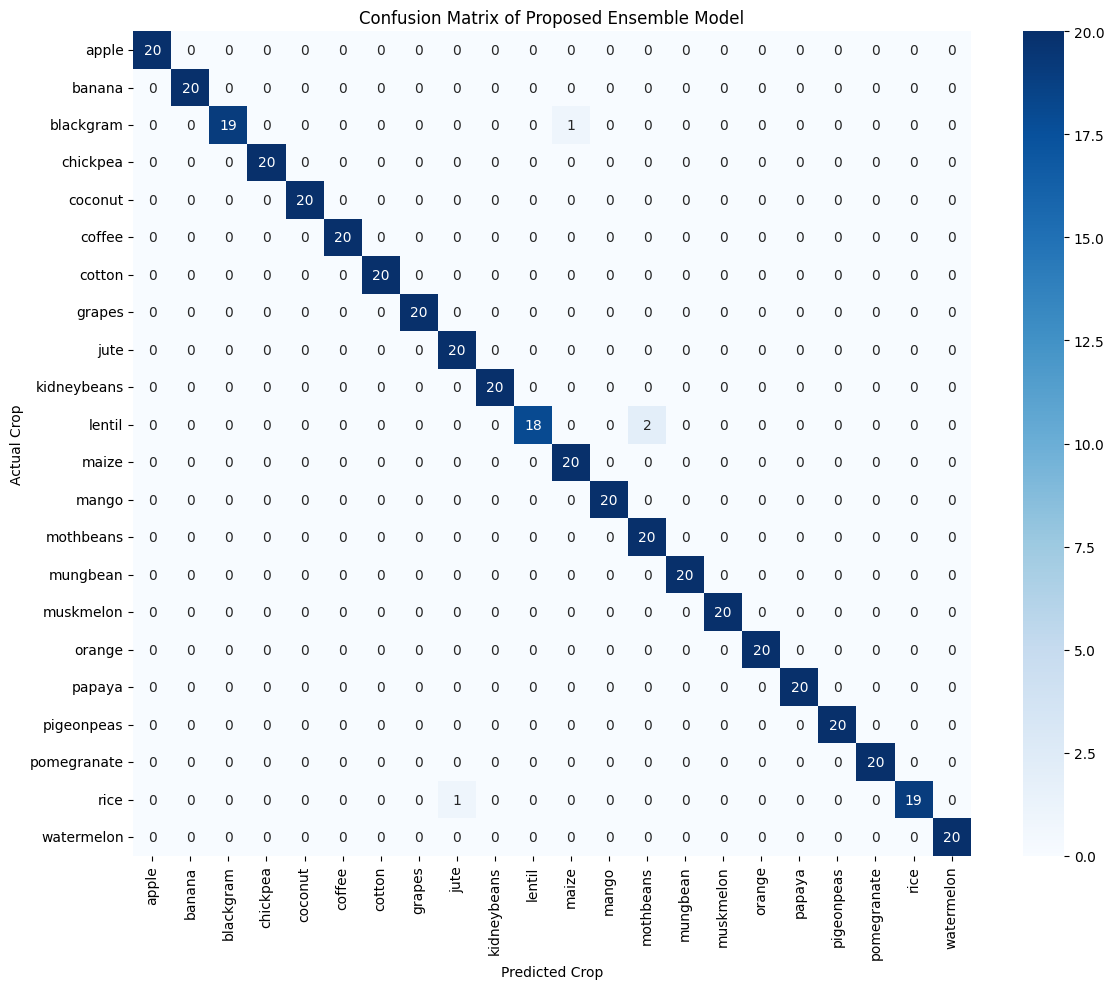

In [49]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,          # SHOW NUMBERS
    fmt="d",             # Integer format
    cmap="Blues",
    xticklabels=ensemble.classes_,
    yticklabels=ensemble.classes_
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Confusion Matrix of Proposed Ensemble Model")

plt.tight_layout()

plt.savefig("../results/figures/confusion_matrix_ensemble.png",
            dpi=300,
            bbox_inches="tight")

plt.show()


Recommended Crop: orange
Prediction Confidence: 98.82%


D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
